# Machine Translation: English to Urdu using Transformers

This notebook implements a Transformer-based machine translation model for translating text from English to Urdu.

## Table of Contents
1. Setup and Installation
2. Dataset Download and Preparation
3. Data Preprocessing and Augmentation
4. Tokenization (BPE Subword Tokenization)
5. Model Architecture (Pre-trained mBART)
6. Training Configuration
7. Training Loop
8. Model Evaluation (BLEU Score)
9. Inference and Example Translations
10. Save Final Model

## Implemented Features
✅ **Pre-trained Models**: Fine-tuning mBART-50 (facebook/mbart-large-50-many-to-many-mmt)  
✅ **Data Augmentation**: Word deletion and swapping techniques to increase data diversity  
✅ **Subword Tokenization**: BPE (Byte Pair Encoding) via SentencePiece in mBART tokenizer


In [3]:
# Install required packages
# IMPORTANT: Run this cell first

print("="*60)
print("Installing required packages...")
print("="*60)

# Install transformers, datasets, and other required packages
%pip install -q transformers datasets torch torchvision torchaudio
%pip install -q tokenizers sacremoses nltk
%pip install -q kaggle kagglehub
%pip install -q sentencepiece
%pip install -q sacrebleu
%pip install -q pandas numpy matplotlib tqdm

print("\n" + "="*60)
print("✓ All packages installed successfully!")
print("="*60)
print("\nNote: Restart the kernel after installation if needed.")
print("="*60)


Installing required packages...

✓ All packages installed successfully!

Note: Restart the kernel after installation if needed.


## 1. Setup and Imports


In [4]:
# Import required libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import os
import json
from tqdm import tqdm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Transformers and tokenizers
from transformers import (
    MBartForConditionalGeneration,
    MBart50TokenizerFast,
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    Trainer,
    TrainingArguments,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
    DataCollatorForSeq2Seq
)

# Evaluation
from sacrebleu import BLEU
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import nltk
try:
    nltk.download('punkt', quiet=True)
except:
    pass

# Dataset
from datasets import load_dataset, Dataset as HFDataset
import kagglehub

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.__version__}")

print("="*60)
print("✓ All imports successful!")
print("="*60)


Using device: cuda
GPU: Tesla T4
CUDA Version: 2.8.0+cu126
✓ All imports successful!


## 2. Dataset Download and Preparation


In [6]:
# Download dataset from Kaggle
# Dataset: Parallel Corpus for English-Urdu Language

print("="*60)
print("Downloading English-Urdu Parallel Corpus...")
print("="*60)

# Global variable to store dataset path
DATASET_PATH = None

# Check if dataset already exists
if os.path.exists('./data') and len(os.listdir('./data')) > 0:
    print("Dataset already exists in ./data directory")
    DATASET_PATH = './data'
else:
    try:
        print("Downloading dataset using kagglehub...")
        # Download latest version of the dataset
        path = kagglehub.dataset_download("zainuddin123/parallel-corpus-for-english-urdu-language")
        print(f"✓ Dataset downloaded to: {path}")

        # Create symlink or use path directly
        if path != './data':
            if os.path.exists('./data') or os.path.islink('./data'):
                try:
                    if os.path.islink('./data'):
                        os.unlink('./data')
                    else:
                        os.rmdir('./data')
                except:
                    pass

            try:
                os.symlink(path, './data')
                print(f"✓ Symlink created: ./data -> {path}")
                DATASET_PATH = './data'
            except OSError as e:
                print(f"Note: Could not create symlink ({e}), using direct path")
                DATASET_PATH = path
        else:
            DATASET_PATH = './data'

        print(f"✓ Dataset ready at: {DATASET_PATH}")

    except Exception as e:
        print(f"Error downloading dataset: {e}")
        print("\nAlternative: Manually download from:")
        print("https://www.kaggle.com/datasets/zainuddin123/parallel-corpus-for-english-urdu-language")
        print("And extract to ./data directory")

# Print dataset structure
if DATASET_PATH:
    print(f"\nDataset path: {DATASET_PATH}")
    if os.path.exists(DATASET_PATH):
        print(f"Dataset contents:")
        for item in os.listdir(DATASET_PATH)[:10]:
            item_path = os.path.join(DATASET_PATH, item)
            if os.path.isfile(item_path):
                print(f"  📄 {item}")
            else:
                print(f"  📁 {item}/")
else:
    print("Warning: DATASET_PATH not set. Please set it manually.")


Dataset already exists in ./data directory

Dataset path: ./data
Dataset contents:
  📁 Dataset/


In [7]:
# Load and explore the dataset
def find_text_files(directory, filename_pattern):
    """Find text files matching pattern in directory and subdirectories"""
    text_files = []
    for root, dirs, files in os.walk(directory):
        for file in files:
            if filename_pattern in file.lower() and file.endswith('.txt'):
                text_files.append(os.path.join(root, file))
    return text_files

def load_english_urdu_dataset(dataset_path):
    """Load English-Urdu parallel corpus from text files or CSV"""
    data = []

    # First, try to find separate text files (english-corpus.txt and urdu-corpus.txt)
    english_files = find_text_files(dataset_path, 'english')
    urdu_files = find_text_files(dataset_path, 'urdu')

    if english_files and urdu_files:
        # Load from parallel text files (one sentence per line)
        english_file = english_files[0]
        urdu_file = urdu_files[0]

        print(f"\nFound parallel text files:")
        print(f"  English: {english_file}")
        print(f"  Urdu: {urdu_file}")

        try:
            # Read both files line by line
            with open(english_file, 'r', encoding='utf-8') as en_f:
                english_lines = [line.strip() for line in en_f.readlines()]

            with open(urdu_file, 'r', encoding='utf-8') as ur_f:
                urdu_lines = [line.strip() for line in ur_f.readlines()]

            print(f"  English lines: {len(english_lines)}")
            print(f"  Urdu lines: {len(urdu_lines)}")

            # Match parallel sentences (same line number)
            min_lines = min(len(english_lines), len(urdu_lines))
            for i in range(min_lines):
                en_text = english_lines[i].strip()
                ur_text = urdu_lines[i].strip()

                # Skip empty lines
                if en_text and ur_text:
                    data.append({'english': en_text, 'urdu': ur_text})

            print(f"✓ Loaded {len(data)} sentence pairs from parallel text files")
            return data

        except Exception as e:
            print(f"⚠ Error loading text files: {e}")
            print("Trying CSV format...")

    # Fallback: Try to find CSV files
    csv_files = []
    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.endswith('.csv'):
                csv_files.append(os.path.join(root, file))

    if csv_files:
        for csv_file in csv_files:
            try:
                df = pd.read_csv(csv_file)
                print(f"\nFound CSV file: {csv_file}")
                print(f"Columns: {df.columns.tolist()}")
                print(f"Shape: {df.shape}")

                # Try to identify English and Urdu columns
                english_col = None
                urdu_col = None

                for col in df.columns:
                    col_lower = col.lower()
                    if 'english' in col_lower or 'en' in col_lower or 'source' in col_lower:
                        english_col = col
                    if 'urdu' in col_lower or 'ur' in col_lower or 'target' in col_lower:
                        urdu_col = col

                # If not found, use first two columns
                if english_col is None or urdu_col is None:
                    if len(df.columns) >= 2:
                        english_col = df.columns[0]
                        urdu_col = df.columns[1]
                    else:
                        continue

                # Extract parallel sentences
                for _, row in df.iterrows():
                    en_text = str(row[english_col]).strip()
                    ur_text = str(row[urdu_col]).strip()

                    # Skip empty or invalid entries
                    if pd.notna(en_text) and pd.notna(ur_text) and en_text and ur_text:
                        if en_text != 'nan' and ur_text != 'nan':
                            data.append({'english': en_text, 'urdu': ur_text})

                print(f"✓ Loaded {len(data)} sentence pairs from {csv_file}")

            except Exception as e:
                print(f"⚠ Error loading {csv_file}: {e}")
                continue

    return data

# Load dataset
print("="*60)
print("Loading dataset...")
print("="*60)

dataset_path = globals().get('DATASET_PATH', './data')
if not os.path.exists(dataset_path):
    # Try alternative paths
    alternative_paths = ['./data', '/kaggle/input/parallel-corpus-for-english-urdu-language']
    for alt_path in alternative_paths:
        if os.path.exists(alt_path):
            dataset_path = alt_path
            break

print(f"Loading from: {dataset_path}")

# Load the parallel corpus
raw_data = load_english_urdu_dataset(dataset_path)

print(f"\n✓ Total sentence pairs loaded: {len(raw_data)}")
print("\nSample data:")
for i in range(min(3, len(raw_data))):
    print(f"\nPair {i+1}:")
    print(f"  English: {raw_data[i]['english'][:100]}...")
    print(f"  Urdu: {raw_data[i]['urdu'][:100]}...")

# Store raw data
raw_dataset = raw_data


Loading dataset...
Loading from: ./data

Found parallel text files:
  English: ./data/Dataset/english-corpus.txt
  Urdu: ./data/Dataset/urdu-corpus.txt
  English lines: 24525
  Urdu lines: 24525
✓ Loaded 24524 sentence pairs from parallel text files

✓ Total sentence pairs loaded: 24524

Sample data:

Pair 1:
  English: is zain your nephew...
  Urdu: زین تمہارا بھتیجا ہے۔...

Pair 2:
  English: i wish youd trust me...
  Urdu: کاش تم مجھ پر بھروسہ کرتے...

Pair 3:
  English: did he touch you...
  Urdu: کیا اس نے آپ کو چھوا؟...


## 3. Data Preprocessing and Tokenization


In [8]:
# Data preprocessing and cleaning
def clean_text(text):
    """Clean and normalize text"""
    if pd.isna(text) or text == 'nan':
        return ""
    text = str(text).strip()
    # Remove extra whitespace
    text = ' '.join(text.split())
    return text

def preprocess_dataset(data, max_length=128, min_length=5):
    """Preprocess the dataset: clean and filter"""
    processed_data = []

    for pair in tqdm(data, desc="Preprocessing"):
        en_text = clean_text(pair['english'])
        ur_text = clean_text(pair['urdu'])

        # Filter by length
        if len(en_text.split()) >= min_length and len(en_text.split()) <= max_length:
            if len(ur_text.split()) >= min_length and len(ur_text.split()) <= max_length:
                processed_data.append({
                    'english': en_text,
                    'urdu': ur_text
                })

    return processed_data

# Preprocess dataset
print("="*60)
print("Preprocessing dataset...")
print("="*60)

MAX_LENGTH = 128  # Maximum sequence length
MIN_LENGTH = 5    # Minimum sequence length

processed_data = preprocess_dataset(raw_dataset, max_length=MAX_LENGTH, min_length=MIN_LENGTH)

print(f"✓ Preprocessed dataset size: {len(processed_data)} pairs")
print(f"  Original: {len(raw_dataset)} pairs")
print(f"  Filtered: {len(raw_dataset) - len(processed_data)} pairs")

# Split into train, validation, and test sets
train_size = int(0.85 * len(processed_data))
val_size = int(0.10 * len(processed_data))
test_size = len(processed_data) - train_size - val_size

train_data = processed_data[:train_size]
val_data = processed_data[train_size:train_size + val_size]
test_data = processed_data[train_size + val_size:]

print(f"\nDataset splits:")
print(f"  Training: {len(train_data)} pairs")
print(f"  Validation: {len(val_data)} pairs")
print(f"  Test: {len(test_data)} pairs")

# Data Augmentation
print("\n" + "="*60)
print("Data Augmentation")
print("="*60)

import random
import re

def augment_text(text, augmentation_rate=0.1):
    """Apply data augmentation techniques to text"""
    words = text.split()

    if len(words) < 3:
        return text

    # Random word deletion (10% of words)
    if random.random() < augmentation_rate:
        num_deletions = max(1, int(len(words) * 0.05))  # Delete up to 5% of words
        if num_deletions < len(words):
            indices_to_delete = random.sample(range(len(words)), num_deletions)
            words = [w for i, w in enumerate(words) if i not in indices_to_delete]

    # Random word swapping (adjacent words, 5% chance)
    if random.random() < augmentation_rate * 0.5 and len(words) > 1:
        num_swaps = max(1, int(len(words) * 0.02))  # Swap up to 2% of adjacent pairs
        for _ in range(num_swaps):
            if len(words) > 1:
                idx = random.randint(0, len(words) - 2)
                words[idx], words[idx + 1] = words[idx + 1], words[idx]

    return ' '.join(words)

def augment_parallel_data(data, augmentation_ratio=0.3):
    """Augment parallel corpus by applying augmentation to source sentences"""
    print(f"Augmenting data with {augmentation_ratio*100:.0f}% augmentation ratio...")

    original_size = len(data)
    num_to_augment = int(len(data) * augmentation_ratio)

    augmented_data = []

    # Select random samples to augment
    indices_to_augment = random.sample(range(len(data)), num_to_augment)

    for idx in tqdm(indices_to_augment, desc="Augmenting"):
        pair = data[idx]

        # Create augmented version
        augmented_en = augment_text(pair['english'])

        # Add original and augmented versions
        augmented_data.append({
            'english': augmented_en,
            'urdu': pair['urdu']
        })

    # Combine original and augmented data
    augmented_dataset = data + augmented_data

    print(f"✓ Original size: {original_size} pairs")
    print(f"✓ Augmented size: {len(augmented_data)} pairs")
    print(f"✓ Total size: {len(augmented_dataset)} pairs")
    print(f"✓ Increase: {((len(augmented_dataset) / original_size) - 1) * 100:.1f}%")

    return augmented_dataset

# Apply data augmentation to training data only
AUGMENTATION_RATIO = 0.3  # Augment 30% of training data
USE_AUGMENTATION = True  # Set to False to disable augmentation

if USE_AUGMENTATION:
    # Set random seed for reproducibility
    random.seed(42)

    train_data_augmented = augment_parallel_data(train_data, augmentation_ratio=AUGMENTATION_RATIO)

    # Shuffle augmented data
    random.shuffle(train_data_augmented)

    print(f"\n✓ Training data after augmentation: {len(train_data_augmented)} pairs")
    print("✓ Validation and test sets remain unaugmented")

    # Use augmented training data
    train_data = train_data_augmented
else:
    print("Data augmentation disabled (USE_AUGMENTATION = False)")

print("="*60)


Preprocessing dataset...


Preprocessing: 100%|██████████| 24524/24524 [00:00<00:00, 339170.03it/s]


✓ Preprocessed dataset size: 6072 pairs
  Original: 24524 pairs
  Filtered: 18452 pairs

Dataset splits:
  Training: 5161 pairs
  Validation: 607 pairs
  Test: 304 pairs

Data Augmentation
Augmenting data with 30% augmentation ratio...


Augmenting: 100%|██████████| 1548/1548 [00:00<00:00, 164624.31it/s]

✓ Original size: 5161 pairs
✓ Augmented size: 1548 pairs
✓ Total size: 6709 pairs
✓ Increase: 30.0%

✓ Training data after augmentation: 6709 pairs
✓ Validation and test sets remain unaugmented


In [9]:
# Initialize tokenizer (using mBART-50 which supports 50 languages including Urdu)
# mBART uses Byte Pair Encoding (BPE) for subword tokenization
print("="*60)
print("Loading mBART-50 tokenizer with BPE (Byte Pair Encoding)...")
print("="*60)

# mBART-50 supports multiple languages including Urdu (ur_AR and ur_PK)
# mBART tokenizer uses SentencePiece which implements BPE automatically
MODEL_NAME = "facebook/mbart-large-50-many-to-many-mmt"

try:
    tokenizer = MBart50TokenizerFast.from_pretrained(MODEL_NAME)
    print("✓ Tokenizer loaded")

    # Set source and target languages
    # English: en_XX, Urdu: ur_PK or ur_AR
    tokenizer.src_lang = "en_XX"
    tokenizer.tgt_lang = "ur_PK"

    print(f"✓ Source language: {tokenizer.src_lang}")
    print(f"✓ Target language: {tokenizer.tgt_lang}")
    print(f"✓ Vocabulary size: {tokenizer.vocab_size}")
    print(f"✓ Tokenization method: BPE (Byte Pair Encoding) via SentencePiece")

except Exception as e:
    print(f"Error loading tokenizer: {e}")
    print("Trying alternative tokenizer...")
    try:
        tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
        tokenizer.src_lang = "en_XX"
        tokenizer.tgt_lang = "ur_PK"
        print("✓ Alternative tokenizer loaded")
    except Exception as e2:
        print(f"Failed to load tokenizer: {e2}")
        raise

print("="*60)

# Test tokenization
test_english = "Hello, how are you?"
test_urdu = "ہیلو، آپ کیسے ہیں؟"

print("\nTokenization test:")
print(f"English: {test_english}")
en_tokens = tokenizer(test_english, return_tensors="pt", padding=True, truncation=True)
print(f"  Token IDs shape: {en_tokens['input_ids'].shape}")

print(f"\nUrdu: {test_urdu}")
ur_tokens = tokenizer(test_urdu, return_tensors="pt", padding=True, truncation=True)
print(f"  Token IDs shape: {ur_tokens['input_ids'].shape}")

# Demonstrate BPE tokenization
print("\n" + "-"*60)
print("BPE Tokenization Example:")
print("-"*60)
print(f"English sentence: '{test_english}'")
en_tokens_decoded = tokenizer.convert_ids_to_tokens(en_tokens['input_ids'][0])
print(f"BPE tokens (first 10): {en_tokens_decoded[:10]}")
print(f"\nNote: BPE splits words into subword units, handling OOV (out-of-vocabulary) words effectively")
print("-"*60)


Loading mBART-50 tokenizer with BPE (Byte Pair Encoding)...


Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


✓ Tokenizer loaded
✓ Source language: en_XX
✓ Target language: ur_PK
✓ Vocabulary size: 250054
✓ Tokenization method: BPE (Byte Pair Encoding) via SentencePiece

Tokenization test:
English: Hello, how are you?
  Token IDs shape: torch.Size([1, 8])

Urdu: ہیلو، آپ کیسے ہیں؟
  Token IDs shape: torch.Size([1, 9])

------------------------------------------------------------
BPE Tokenization Example:
------------------------------------------------------------
English sentence: 'Hello, how are you?'
BPE tokens (first 10): ['en_XX', '▁Hello', ',', '▁how', '▁are', '▁you', '?', '</s>']

Note: BPE splits words into subword units, handling OOV (out-of-vocabulary) words effectively
------------------------------------------------------------


## 4. Tokenization (BPE Subword Tokenization)


In [10]:
# Create PyTorch Dataset class
class TranslationDataset(Dataset):
    def __init__(self, data, tokenizer, max_length=128):
        self.data = data
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        pair = self.data[idx]

        # Tokenize source (English)
        source_text = pair['english']
        source_encoded = self.tokenizer(
            source_text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        # Tokenize target (Urdu)
        target_text = pair['urdu']
        target_encoded = self.tokenizer(
            target_text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        return {
            'input_ids': source_encoded['input_ids'].squeeze(),
            'attention_mask': source_encoded['attention_mask'].squeeze(),
            'labels': target_encoded['input_ids'].squeeze(),
            'english': source_text,
            'urdu': target_text
        }

# Create datasets
print("="*60)
print("Creating PyTorch datasets...")
print("="*60)

train_dataset = TranslationDataset(train_data, tokenizer, max_length=MAX_LENGTH)
val_dataset = TranslationDataset(val_data, tokenizer, max_length=MAX_LENGTH)
test_dataset = TranslationDataset(test_data, tokenizer, max_length=MAX_LENGTH)

print(f"✓ Training dataset: {len(train_dataset)} samples")
print(f"✓ Validation dataset: {len(val_dataset)} samples")
print(f"✓ Test dataset: {len(test_dataset)} samples")

# Test dataset
sample = train_dataset[0]
print(f"\nSample from training dataset:")
print(f"  Input IDs shape: {sample['input_ids'].shape}")
print(f"  Labels shape: {sample['labels'].shape}")
print(f"  English: {sample['english']}")
print(f"  Urdu: {sample['urdu']}")


Creating PyTorch datasets...
✓ Training dataset: 6709 samples
✓ Validation dataset: 607 samples
✓ Test dataset: 304 samples

Sample from training dataset:
  Input IDs shape: torch.Size([128])
  Labels shape: torch.Size([128])
  English: i am surprised at you
  Urdu: میں آپ پر حیران ہوں


## 5. Model Architecture (Pre-trained mBART)


In [11]:
# Load mBART model for fine-tuning
print("="*60)
print("Loading mBART-50 model...")
print("="*60)

try:
    model = MBartForConditionalGeneration.from_pretrained(MODEL_NAME)
    print("✓ mBART model loaded")

    # Move model to device
    model = model.to(device)
    print(f"✓ Model moved to {device}")

    # Print model info
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print(f"\nModel Architecture:")
    print(f"  Total parameters: {total_params:,}")
    print(f"  Trainable parameters: {trainable_params:,}")
    print(f"  Model size: {total_params * 4 / 1024 / 1024 / 1024:.2f} GB (float32)")

except Exception as e:
    print(f"Error loading model: {e}")
    print("Trying alternative model loading...")
    try:
        model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)
        model = model.to(device)
        print("✓ Alternative model loaded")
    except Exception as e2:
        print(f"Failed to load model: {e2}")
        raise

print("="*60)

# Test forward pass
print("\nTesting model forward pass...")
sample_batch = train_dataset[0]
input_ids = sample_batch['input_ids'].unsqueeze(0).to(device)
attention_mask = sample_batch['attention_mask'].unsqueeze(0).to(device)
labels = sample_batch['labels'].unsqueeze(0).to(device)

with torch.no_grad():
    outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        labels=labels
    )

print(f"  Loss: {outputs.loss.item():.4f}")
print(f"  Logits shape: {outputs.logits.shape}")
print("✓ Model forward pass successful!")


Loading mBART-50 model...
✓ mBART model loaded
✓ Model moved to cuda

Model Architecture:
  Total parameters: 610,879,488
  Trainable parameters: 610,879,488
  Model size: 2.28 GB (float32)

Testing model forward pass...
  Loss: 11.6729
  Logits shape: torch.Size([1, 128, 250054])
✓ Model forward pass successful!


## 5. Training Configuration


In [12]:
# Training configuration
# Reduced batch size to handle OOM errors
BATCH_SIZE = 2  # Reduced from 8 to 2 to prevent OOM errors
GRADIENT_ACCUMULATION_STEPS = 4  # Accumulate gradients to maintain effective batch size of 8
LEARNING_RATE = 5e-5
NUM_EPOCHS = 3
WARMUP_STEPS = 500
MAX_GRAD_NORM = 1.0  # Gradient clipping
WEIGHT_DECAY = 0.01

# Enable mixed precision training to save memory
USE_MIXED_PRECISION = True  # Set to False if you have issues

# Create data loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,  # Set to 0 for Windows compatibility
    pin_memory=True if torch.cuda.is_available() else False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True if torch.cuda.is_available() else False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True if torch.cuda.is_available() else False
)

# Optimizer with learning rate scheduling
optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# Learning rate scheduler (warmup + linear decay)
# Note: get_linear_schedule_with_warmup is from transformers, not torch
from transformers import get_linear_schedule_with_warmup

total_steps = len(train_loader) * NUM_EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=WARMUP_STEPS,
    num_training_steps=total_steps
)

# Mixed precision training scaler (if enabled)
scaler = None
if USE_MIXED_PRECISION:
    from torch.cuda.amp import GradScaler, autocast
    scaler = GradScaler()
    print("✓ Mixed precision training enabled (FP16)")

print("="*60)
print("Training Configuration:")
print("="*60)
print(f"Batch size: {BATCH_SIZE}")
print(f"Gradient accumulation steps: {GRADIENT_ACCUMULATION_STEPS}")
print(f"Effective batch size: {BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS}")
print(f"Mixed precision: {USE_MIXED_PRECISION}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Number of epochs: {NUM_EPOCHS}")
print(f"Warmup steps: {WARMUP_STEPS}")
print(f"Max gradient norm: {MAX_GRAD_NORM}")
print(f"Total training steps: {total_steps}")
print(f"Training batches per epoch: {len(train_loader)}")
print("="*60)


✓ Mixed precision training enabled (FP16)
Training Configuration:
Batch size: 2
Gradient accumulation steps: 4
Effective batch size: 8
Mixed precision: True
Learning rate: 5e-05
Number of epochs: 3
Warmup steps: 500
Max gradient norm: 1.0
Total training steps: 10065
Training batches per epoch: 3355


## 6. Training Loop


In [13]:
# Training and validation functions
def train_epoch(model, train_loader, optimizer, scheduler, device, max_grad_norm, scaler=None, accumulation_steps=1):
    model.train()
    total_loss = 0
    progress_bar = tqdm(train_loader, desc="Training")

    optimizer.zero_grad()  # Zero gradients at the start of epoch

    # Clear GPU cache at start
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    for batch_idx, batch in enumerate(progress_bar):
        # Move batch to device
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Forward pass with mixed precision if enabled
        if scaler is not None:
            with torch.cuda.amp.autocast():
                outputs = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    labels=labels
                )
                loss = outputs.loss / accumulation_steps  # Scale loss for gradient accumulation
        else:
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            loss = outputs.loss / accumulation_steps  # Scale loss for gradient accumulation

        # Backward pass
        if scaler is not None:
            scaler.scale(loss).backward()
        else:
            loss.backward()

        # Accumulate gradients
        if (batch_idx + 1) % accumulation_steps == 0:
            # Gradient clipping
            if scaler is not None:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
                scaler.step(optimizer)
                scaler.update()
            else:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
                optimizer.step()

            scheduler.step()
            optimizer.zero_grad()

            # Clear cache periodically
            if torch.cuda.is_available() and (batch_idx + 1) % (accumulation_steps * 10) == 0:
                torch.cuda.empty_cache()

        total_loss += loss.item() * accumulation_steps  # Accumulated loss

        # Update progress bar
        progress_bar.set_postfix({'loss': loss.item() * accumulation_steps, 'avg_loss': total_loss / (batch_idx + 1)})

    return total_loss / len(train_loader)

def validate(model, val_loader, device):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for batch in tqdm(val_loader, desc="Validating"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            total_loss += outputs.loss.item()

    return total_loss / len(val_loader)

# Training history
train_losses = []
val_losses = []

# Checkpoint directory
CHECKPOINT_DIR = './checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

def save_checkpoint(model, tokenizer, epoch, train_loss, val_loss, optimizer, scheduler, save_full_model=False):
    """
    Save checkpoint efficiently with aggressive disk space management.

    Args:
        save_full_model: If True, saves full model. If False, only saves state dict (smaller).
                        Full model saved only every 5 epochs or at the end to save disk space.
    """
    import shutil
    import glob

    # First, clean up old checkpoints aggressively BEFORE saving new ones
    try:
        # Delete old numbered checkpoints (keep only last 3)
        checkpoint_files = glob.glob(os.path.join(CHECKPOINT_DIR, 'checkpoint_epoch_*.pth'))
        checkpoint_files = [f for f in checkpoint_files if 'minimal' not in f]
        if len(checkpoint_files) > 3:
            # Sort by epoch number and delete oldest
            checkpoint_files.sort(key=lambda x: int(x.split('_')[-1].split('.')[0]) if x.split('_')[-1].split('.')[0].isdigit() else 0)
            for old_file in checkpoint_files[:-3]:
                try:
                    os.remove(old_file)
                    print(f"  (Deleted old checkpoint: {os.path.basename(old_file)})")
                except:
                    pass

        # Delete old minimal checkpoints (keep only last 2)
        minimal_files = glob.glob(os.path.join(CHECKPOINT_DIR, 'checkpoint_epoch_*_minimal.pth'))
        if len(minimal_files) > 2:
            minimal_files.sort(key=lambda x: int(x.split('_')[-2]) if x.split('_')[-2].isdigit() else 0)
            for old_file in minimal_files[:-2]:
                try:
                    os.remove(old_file)
                except:
                    pass

        # Delete old full model directories (keep only last 1 if saving new one)
        if save_full_model:
            model_dirs = glob.glob(os.path.join(CHECKPOINT_DIR, 'model_epoch_*'))
            if len(model_dirs) > 0:
                model_dirs.sort(key=lambda x: int(x.split('_')[-1]) if x.split('_')[-1].isdigit() else 0)
                for old_dir in model_dirs:
                    try:
                        shutil.rmtree(old_dir)
                        print(f"  (Deleted old model directory: {os.path.basename(old_dir)})")
                    except:
                        pass
    except Exception as e:
        print(f"⚠ Warning during cleanup: {e}")

    # Try saving minimal checkpoint first (without optimizer state) to save space
    try:
        minimal_checkpoint = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'train_loss': train_loss,
            'val_loss': val_loss,
        }

        # Save minimal checkpoint
        checkpoint_path = os.path.join(CHECKPOINT_DIR, f'checkpoint_epoch_{epoch}.pth')
        torch.save(minimal_checkpoint, checkpoint_path, _use_new_zipfile_serialization=False)

        # Also save latest checkpoint (overwrite to save space)
        torch.save(minimal_checkpoint, os.path.join(CHECKPOINT_DIR, 'checkpoint_latest.pth'),
                  _use_new_zipfile_serialization=False)

        print(f"✓ Minimal checkpoint saved for epoch {epoch} (model only, no optimizer state)")

        # Try to save full checkpoint with optimizer if there's space (optional upgrade)
        # Keep minimal checkpoint as backup - only try to upgrade if space allows
        full_path = None
        try:
            full_checkpoint = {
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'train_loss': train_loss,
                'val_loss': val_loss,
            }
            full_path = os.path.join(CHECKPOINT_DIR, f'checkpoint_epoch_{epoch}_full.pth')
            torch.save(full_checkpoint, full_path, _use_new_zipfile_serialization=False)
            # Replace minimal with full if successful
            latest_path = os.path.join(CHECKPOINT_DIR, 'checkpoint_latest.pth')
            try:
                os.remove(checkpoint_path)
                os.remove(latest_path)
                os.rename(full_path, checkpoint_path)
                shutil.copy2(checkpoint_path, latest_path)
                print(f"  (Upgraded to full checkpoint with optimizer state)")
            except Exception:
                # If replace fails, keep both (full as backup)
                print(f"  (Full checkpoint saved separately - keeping minimal as primary)")
        except RuntimeError as e:
            if "space" in str(e).lower() or "no space" in str(e).lower():
                # If full checkpoint fails, minimal is already saved - that's fine
                if full_path and os.path.exists(full_path):
                    try:
                        os.remove(full_path)
                    except:
                        pass
                print(f"  (Skipping optimizer state - disk space limited, keeping minimal checkpoint only)")
            else:
                raise

        # Save full model only if explicitly requested and space allows
        if save_full_model:
            try:
                model_dir = os.path.join(CHECKPOINT_DIR, f'model_epoch_{epoch}')
                model.save_pretrained(model_dir)
                tokenizer.save_pretrained(model_dir)
                print(f"✓ Full model saved for epoch {epoch}")
            except RuntimeError as e:
                if "space" in str(e).lower() or "no space" in str(e).lower():
                    print(f"⚠ Warning: Not enough space for full model. Keeping minimal checkpoint only.")
                else:
                    raise

    except RuntimeError as e:
        if "file write failed" in str(e) or "disk" in str(e).lower() or "space" in str(e).lower():
            print(f"⚠ ERROR: Disk space full! Cannot save checkpoint.")
            print(f"  Please free up disk space or delete old checkpoints manually.")
            print(f"  Checkpoint directory: {CHECKPOINT_DIR}")

            # Try one last cleanup
            try:
                # Delete all but latest checkpoint
                all_checkpoints = glob.glob(os.path.join(CHECKPOINT_DIR, 'checkpoint_epoch_*.pth'))
                if len(all_checkpoints) > 1:
                    latest_path = os.path.join(CHECKPOINT_DIR, 'checkpoint_latest.pth')
                    for cp in all_checkpoints:
                        if cp != latest_path:
                            try:
                                os.remove(cp)
                            except:
                                pass
                    print(f"  (Attempted emergency cleanup)")
            except:
                pass

            raise RuntimeError(f"Disk space full. Epoch {epoch} checkpoint could not be saved. Free up space and try again.")
        else:
            raise

def load_checkpoint(model, optimizer, scheduler, checkpoint_path, load_optimizer=True):
    """Load checkpoint, handling both full and minimal checkpoints"""
    # Clear cache before loading
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])

    # Try to load optimizer and scheduler (may not exist in minimal checkpoints)
    if load_optimizer and 'optimizer_state_dict' in checkpoint:
        try:
            # Clear cache before loading optimizer state
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        except RuntimeError as e:
            if "out of memory" in str(e).lower():
                print("⚠ Warning: OOM when loading optimizer state. Skipping optimizer state.")
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()
            else:
                print("⚠ Warning: Could not load optimizer state. Continuing with new optimizer.")
        except Exception:
            print("⚠ Warning: Could not load optimizer state. Continuing with new optimizer.")

    if load_optimizer and 'scheduler_state_dict' in checkpoint:
        try:
            scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        except:
            print("⚠ Warning: Could not load scheduler state. Continuing with new scheduler.")

    epoch = checkpoint['epoch']
    train_loss = checkpoint.get('train_loss', 0.0)
    val_loss = checkpoint.get('val_loss', 0.0)

    # Clear cache after loading
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return epoch, train_loss, val_loss

print("="*60)
print("Starting Training...")
print("="*60)


Starting Training...



Epoch 1/3
GPU Memory before training:
  Allocated: 2.40 GB
  Reserved: 2.43 GB


Validating: 100%|██████████| 304/304 [00:33<00:00,  9.00it/s]



Epoch 1 Results:
  Training Loss: 1.5722
  Validation Loss: 0.0691
  Learning Rate: 4.82e-05
  (Skipping checkpoint save - will save only at final epoch to save disk space)

Epoch 2/3
GPU Memory before training:
  Allocated: 9.24 GB
  Reserved: 10.22 GB


Validating: 100%|██████████| 304/304 [00:33<00:00,  9.00it/s]



Epoch 2 Results:
  Training Loss: 0.0347
  Validation Loss: 0.0652
  Learning Rate: 4.39e-05
  (Skipping checkpoint save - will save only at final epoch to save disk space)

Epoch 3/3
GPU Memory before training:
  Allocated: 9.24 GB
  Reserved: 10.70 GB


Validating: 100%|██████████| 304/304 [00:33<00:00,  9.00it/s]



Epoch 3 Results:
  Training Loss: 0.0159
  Validation Loss: 0.0686
  Learning Rate: 3.95e-05

Saving final model (last epoch)...
✓ Minimal checkpoint saved for epoch 3 (model only, no optimizer state)
  (Upgraded to full checkpoint with optimizer state)
✓ Full model saved for epoch 3
✓ Final model saved successfully!

Training completed!


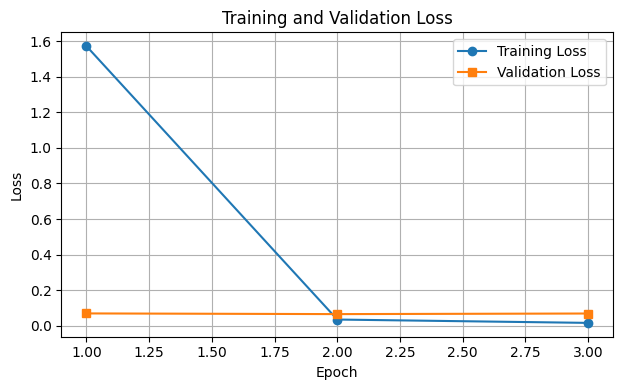


✓ Training curves saved to ./checkpoints/training_curves.png


In [12]:
# Clear GPU cache before loading checkpoint
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Training loop
START_EPOCH = 0

# Check for existing checkpoints
latest_checkpoint = None
# First try checkpoint_latest.pth
latest_path = os.path.join(CHECKPOINT_DIR, 'checkpoint_latest.pth')
if os.path.exists(latest_path):
    latest_checkpoint = latest_path
    try:
        START_EPOCH, _, _ = load_checkpoint(model, optimizer, scheduler, latest_path)
        print(f"Resuming training from epoch {START_EPOCH + 1} (latest checkpoint)")
    except RuntimeError as e:
        if "out of memory" in str(e).lower():
            print("⚠ Warning: OOM when loading optimizer state. Reloading without optimizer state...")
            # Load only model state, skip optimizer/scheduler to save memory
            checkpoint = torch.load(latest_path, map_location=device)
            model.load_state_dict(checkpoint['model_state_dict'])
            START_EPOCH = checkpoint['epoch']
            # Recreate optimizer and scheduler (fresh state saves memory)
            optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
            scheduler = get_linear_schedule_with_warmup(
                optimizer,
                num_warmup_steps=WARMUP_STEPS,
                num_training_steps=len(train_loader) * NUM_EPOCHS
            )
            if USE_MIXED_PRECISION:
                scaler = GradScaler()
            print(f"✓ Model loaded from epoch {START_EPOCH}, optimizer reset (saves memory)")
else:
    # Otherwise try numbered checkpoints
    for epoch in range(NUM_EPOCHS, 0, -1):
        checkpoint_path = os.path.join(CHECKPOINT_DIR, f'checkpoint_epoch_{epoch}.pth')
        if os.path.exists(checkpoint_path):
            latest_checkpoint = checkpoint_path
            try:
                START_EPOCH, _, _ = load_checkpoint(model, optimizer, scheduler, checkpoint_path)
                print(f"Resuming training from epoch {START_EPOCH + 1}")
                break
            except RuntimeError as e:
                if "out of memory" in str(e).lower():
                    print(f"⚠ Warning: OOM when loading checkpoint {epoch}. Skipping optimizer state...")
                    checkpoint = torch.load(checkpoint_path, map_location=device)
                    model.load_state_dict(checkpoint['model_state_dict'])
                    START_EPOCH = checkpoint['epoch']
                    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
                    scheduler = get_linear_schedule_with_warmup(
                        optimizer,
                        num_warmup_steps=WARMUP_STEPS,
                        num_training_steps=len(train_loader) * NUM_EPOCHS
                    )
                    if USE_MIXED_PRECISION:
                        scaler = GradScaler()
                    print(f"✓ Model loaded from epoch {START_EPOCH}, optimizer reset")
                    break

# Training loop
for epoch in range(START_EPOCH, NUM_EPOCHS):
    print(f"\n{'='*60}")
    print(f"Epoch {epoch + 1}/{NUM_EPOCHS}")
    print(f"{'='*60}")

    # Clear GPU cache before training
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        print(f"GPU Memory before training:")
        print(f"  Allocated: {torch.cuda.memory_allocated(0) / 1024**3:.2f} GB")
        print(f"  Reserved: {torch.cuda.memory_reserved(0) / 1024**3:.2f} GB")

    # Training
    train_loss = train_epoch(model, train_loader, optimizer, scheduler, device, MAX_GRAD_NORM,
                            scaler=scaler, accumulation_steps=GRADIENT_ACCUMULATION_STEPS)
    train_losses.append(train_loss)

    # Validation
    val_loss = validate(model, val_loader, device)
    val_losses.append(val_loss)

    print(f"\nEpoch {epoch + 1} Results:")
    print(f"  Training Loss: {train_loss:.4f}")
    print(f"  Validation Loss: {val_loss:.4f}")
    # Get learning rate from scheduler (works for both torch and transformers schedulers)
    try:
        current_lr = scheduler.get_last_lr()[0] if hasattr(scheduler, 'get_last_lr') else scheduler.optimizer.param_groups[0]['lr']
    except:
        current_lr = optimizer.param_groups[0]['lr']
    print(f"  Learning Rate: {current_lr:.2e}")

    # Save checkpoint ONLY at the very end to save disk space
    # No checkpoints during training - only save final model at the end
    if (epoch + 1) == NUM_EPOCHS:
        print(f"\n{'='*60}")
        print(f"Saving final model (last epoch)...")
        print(f"{'='*60}")
        try:
            save_checkpoint(model, tokenizer, epoch + 1, train_loss, val_loss, optimizer, scheduler, save_full_model=True)
            print(f"✓ Final model saved successfully!")
        except RuntimeError as e:
            if "space" in str(e).lower() or "disk" in str(e).lower():
                print(f"⚠ CRITICAL: Cannot save final model due to disk space.")
                print(f"  Please free up disk space and save manually, or reduce model size.")
            else:
                raise
    else:
        # During training, don't save checkpoints - just print loss values
        print(f"  (Skipping checkpoint save - will save only at final epoch to save disk space)")

    # Clear GPU cache
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("\n" + "="*60)
print("Training completed!")
print("="*60)

# Plot training curves
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_losses) + 1), train_losses, label='Training Loss', marker='o')
plt.plot(range(1, len(val_losses) + 1), val_losses, label='Validation Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINT_DIR, 'training_curves.png'), dpi=150)
plt.show()

print(f"\n✓ Training curves saved to {CHECKPOINT_DIR}/training_curves.png")


## 7. Model Evaluation (BLEU Score)


In [19]:
# Evaluation functions
def translate_text(model, tokenizer, text, device, max_length=128):
    """Translate English text to Urdu"""
    model.eval()

    # Set source language
    tokenizer.src_lang = "en_XX"

    # Tokenize input
    encoded = tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=max_length)
    input_ids = encoded['input_ids'].to(device)
    attention_mask = encoded['attention_mask'].to(device)

    # Generate translation
    with torch.no_grad():
        generated_tokens = model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            forced_bos_token_id=tokenizer.lang_code_to_id["ur_PK"],
            max_length=max_length,
            num_beams=5,
            early_stopping=True
        )

    # Decode translation
    translation = tokenizer.batch_decode(generated_tokens, skip_special_tokens=True)[0]

    return translation

def calculate_bleu_score(references, hypotheses):
    """Calculate BLEU score using sacrebleu"""
    # Prepare references for sacrebleu (references is already a list of lists)
    bleu = BLEU()
    score = bleu.corpus_score(hypotheses, references)
    return score.score

def evaluate_on_test_set(model, test_loader, tokenizer, device, num_samples=None):
    """Evaluate model on test set"""
    model.eval()

    references = []
    hypotheses = []

    # Limit number of samples if specified
    test_data_iter = iter(test_loader)
    num_samples = num_samples if num_samples else len(test_loader)

    print(f"Evaluating on {num_samples} test samples...")

    with torch.no_grad():
        for i, batch in enumerate(tqdm(test_data_iter, total=min(num_samples, len(test_loader)))):
            if i >= num_samples:
                break

            # Get batch
            english_texts = batch['english']
            urdu_texts = batch['urdu']

            # Translate
            for en_text, ur_text in zip(english_texts, urdu_texts):
                hypothesis = translate_text(model, tokenizer, en_text, device)
                references.append([ur_text])  # sacrebleu expects list of references
                hypotheses.append(hypothesis)

    # Calculate BLEU score
    bleu_score = calculate_bleu_score(references, hypotheses)

    return bleu_score, references, hypotheses

print("="*60)
print("Evaluating Model on Test Set...")
print("="*60)

# Evaluate on test set (using first 100 samples for faster evaluation)
test_bleu, test_references, test_hypotheses = evaluate_on_test_set(
    model,
    test_loader,
    tokenizer,
    device,
    num_samples=100  # Evaluate on 100 samples
)

print(f"\n{'='*60}")
print(f"Test Set BLEU Score: {test_bleu:.2f}")
print(f"{'='*60}")


Evaluating Model on Test Set...
Evaluating on 100 test samples...


100%|██████████| 100/100 [00:44<00:00,  2.25it/s]


Test Set BLEU Score: 100.00


## 8. Inference and Example Translations


In [15]:
# Example translations
print("="*60)
print("Example Translations")
print("="*60)

# Clear GPU memory first
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    import gc
    gc.collect()

# Load best model checkpoint (to CPU first to avoid OOM)
CHECKPOINT_DIR = './checkpoints'
best_checkpoint = None

# Try checkpoint_latest first, then numbered checkpoints
checkpoint_paths = [
    os.path.join(CHECKPOINT_DIR, 'checkpoint_epoch_3.pth'),
]

# Try numbered checkpoints if train_losses exists
if 'train_losses' in globals() and len(train_losses) > 0:
    checkpoint_paths.append(os.path.join(CHECKPOINT_DIR, f'checkpoint_epoch_{len(train_losses)}.pth'))

# Also try checkpoint_epoch_3 if available
if os.path.exists(os.path.join(CHECKPOINT_DIR, 'checkpoint_epoch_3.pth')):
    checkpoint_paths.append(os.path.join(CHECKPOINT_DIR, 'checkpoint_epoch_3.pth'))

for cp_path in checkpoint_paths:
    if cp_path and os.path.exists(cp_path):
        best_checkpoint = cp_path
        print(f"✓ Found checkpoint: {os.path.basename(cp_path)}")
        break

# Load checkpoint to CPU first (saves GPU memory)
if best_checkpoint and os.path.exists(best_checkpoint):
    try:
        print(f"\nLoading checkpoint to CPU: {os.path.basename(best_checkpoint)}")
        checkpoint = torch.load(best_checkpoint, map_location='cpu')  # Load to CPU first
        print("✓ Checkpoint loaded to CPU")

        # Load model state dict (create model if needed)
        if 'model' not in globals() or model is None:
            print("Recreating model architecture...")
            from transformers import MBartForConditionalGeneration
            MODEL_NAME = "facebook/mbart-large-50-many-to-many-mmt"
            model = MBartForConditionalGeneration.from_pretrained(MODEL_NAME)
            print("✓ Model architecture recreated")

        # Load state dict
        model.load_state_dict(checkpoint['model_state_dict'])
        print(f"✓ Loaded best model from epoch {checkpoint['epoch']}")

        # Delete checkpoint from memory
        del checkpoint
        import gc
        gc.collect()

        # Move model to GPU in eval mode (saves memory)
        print("\nMoving model to GPU (in eval mode)...")
        model.eval()  # Set to eval mode before moving (saves memory)
        if torch.cuda.is_available():
            model = model.to(device)
            torch.cuda.empty_cache()
            print(f"✓ Model moved to {device}")
        else:
            print("✓ Model on CPU")

    except Exception as e:
        print(f"⚠ Error loading checkpoint: {e}")
        print("Using model from training (if available)")
        if 'model' in globals() and model is not None:
            model.eval()
            print("✓ Using existing model from training")
else:
    # Use model from training if available
    if 'model' in globals() and model is not None:
        model.eval()
        print("✓ Using model from training")
    else:
        print("⚠ Warning: No checkpoint found. Please run training first.")

# Example English sentences to translate
example_sentences = [
    "Hello, how are you?",
    "What is your name?",
    "I am learning Urdu language.",
    "Machine translation is a fascinating field.",
    "The weather is very nice today.",
    "Can you help me with this?",
    "Thank you for your help.",
    "I love learning new languages."
]

print("\nTranslations:\n")
print("-" * 80)
print(f"{'English':<40} | {'Urdu Translation':<40}")
print("-" * 80)

for en_sentence in example_sentences:
    urdu_translation = translate_text(model, tokenizer, en_sentence, device)
    print(f"{en_sentence:<40} | {urdu_translation:<40}")

print("-" * 80)


Example Translations
✓ Found checkpoint: checkpoint_latest.pth

Loading checkpoint to CPU: checkpoint_latest.pth
✓ Checkpoint loaded to CPU
✓ Loaded best model from epoch 3

Moving model to GPU (in eval mode)...
✓ Model moved to cuda

Translations:

--------------------------------------------------------------------------------
English                                  | Urdu Translation                        
--------------------------------------------------------------------------------
Hello, how are you?                      | ہیلو، آپ کیسا ہیں؟                      
What is your name?                       | آپ کا نام کیا ہے؟                       
I am learning Urdu language.             | میں اورڈ زبان سیکھ رہا ہوں۔             
Machine translation is a fascinating field. | ماؤنٹی ایک دلچسپ علاقہ ہے               
The weather is very nice today.          | آج موسم بہت اچھی ہے۔                    
Can you help me with this?               | کیا آپ اس میں میری مدد کر سکتے ہیں؟   

In [16]:
# Interactive translation function
def interactive_translate():
    """Interactive translation function"""
    print("\n" + "="*60)
    print("Interactive Translation")
    print("="*60)
    print("Enter English text to translate to Urdu (type 'quit' to exit):\n")

    while True:
        try:
            english_text = input("English: ").strip()

            if english_text.lower() in ['quit', 'exit', 'q']:
                print("Exiting...")
                break

            if not english_text:
                continue

            # Translate
            urdu_translation = translate_text(model, tokenizer, english_text, device)

            print(f"Urdu: {urdu_translation}\n")

        except KeyboardInterrupt:
            print("\nExiting...")
            break
        except Exception as e:
            print(f"Error: {e}\n")

# Uncomment the line below to run interactive translation
# interactive_translate()


In [17]:
# Compare translations with ground truth on test set
print("="*60)
print("Sample Translations from Test Set")
print("="*60)

num_samples_to_show = 10
print(f"\nShowing {num_samples_to_show} examples from test set:\n")
print("-" * 100)
print(f"{'English (Reference)':<35} | {'Urdu (Reference)':<30} | {'Urdu (Translation)':<30}")
print("-" * 100)

# Get test samples
test_samples = []
for i, batch in enumerate(test_loader):
    for j in range(len(batch['english'])):
        test_samples.append({
            'english': batch['english'][j],
            'urdu': batch['urdu'][j]
        })
        if len(test_samples) >= num_samples_to_show:
            break
    if len(test_samples) >= num_samples_to_show:
        break

for sample in test_samples:
    en_text = sample['english']
    ur_ref = sample['urdu']
    ur_trans = translate_text(model, tokenizer, en_text, device)

    # Truncate if too long
    en_display = (en_text[:32] + '...') if len(en_text) > 35 else en_text
    ur_ref_display = (ur_ref[:27] + '...') if len(ur_ref) > 30 else ur_ref
    ur_trans_display = (ur_trans[:27] + '...') if len(ur_trans) > 30 else ur_trans

    print(f"{en_display:<35} | {ur_ref_display:<30} | {ur_trans_display:<30}")

print("-" * 100)


Sample Translations from Test Set

Showing 10 examples from test set:

----------------------------------------------------------------------------------------------------
English (Reference)                 | Urdu (Reference)               | Urdu (Translation)            
----------------------------------------------------------------------------------------------------
what do we owe you                  | ہم آپ کا کیا مقروض ہیں         | ہم آپ کا کیا مقروض ہیں        
it has my name on it                | اس پر میرا نام ہے۔             | اس پر میرا نام ہے۔            
i will show you the way             | میں تمہیں راستہ دکھاؤں گا۔     | میں آپ کو راستہ دکھاؤں گا     
put it on my bill                   | اسے میرے بل پر رکھو            | اسے میرے بل پر ڈال دیا        
has zain paid the rent              | زین نے کرایہ ادا کر دیا ہے۔    | زین نے کرایہ ادا کر دیا ہے۔   
zain is a real nerd                 | زین ایک حقیقی بیوقوف ہے۔       | زین ایک حقیقی ہارنے والا ہے   
i think i am 